In [2]:
#Lab6 Fahad Saad Almoeili 2230004459 8MA1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

In [3]:
#Task1
# Load cameraman image
image = data.camera()
image = resize(image, (256, 256))

In [4]:
# Get image size
M, N = image.shape

In [5]:
# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

In [6]:
# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

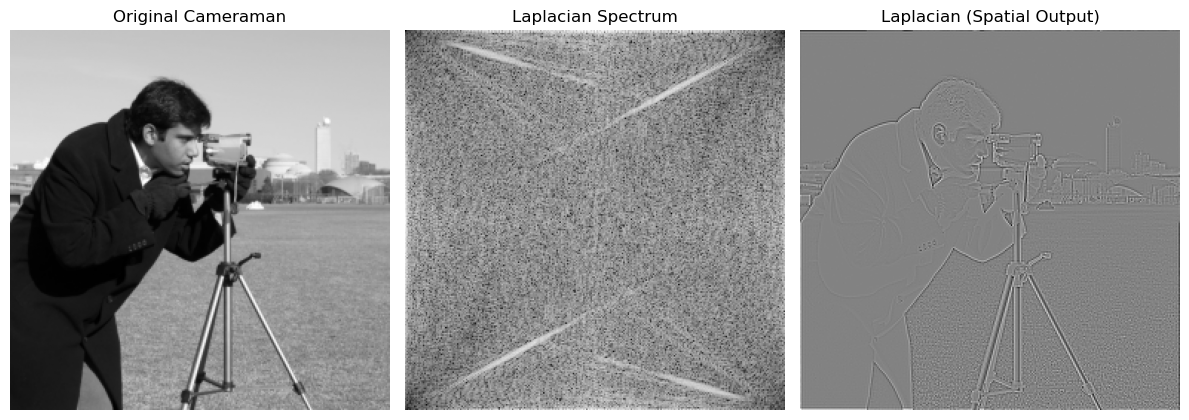

In [9]:
# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
#Task2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift, fftshift

In [11]:
# Load and resize image
image = data.camera()
image = resize(image, (256, 256), anti_aliasing=True)

M, N = image.shape

In [12]:
# Sobel filters
sobel_x = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]], dtype=float)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=float)

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape, dtype=float)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2 : cy - kh//2 + kh,
           cx - kw//2 : cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))

In [13]:
# Compute FFT of image
F = fft2(image)

In [14]:
# FFT of centered Sobel filters (use the provided function)
H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

# Multiply in the frequency domain
F_sobel_x = F * H_x
F_sobel_y = F * H_y

# Back to spatial domain
sobel_x_img = ifft2(F_sobel_x).real
sobel_y_img = ifft2(F_sobel_y).real
sobel_magnitude = np.sqrt(sobel_x_img**2 + sobel_y_img**2)

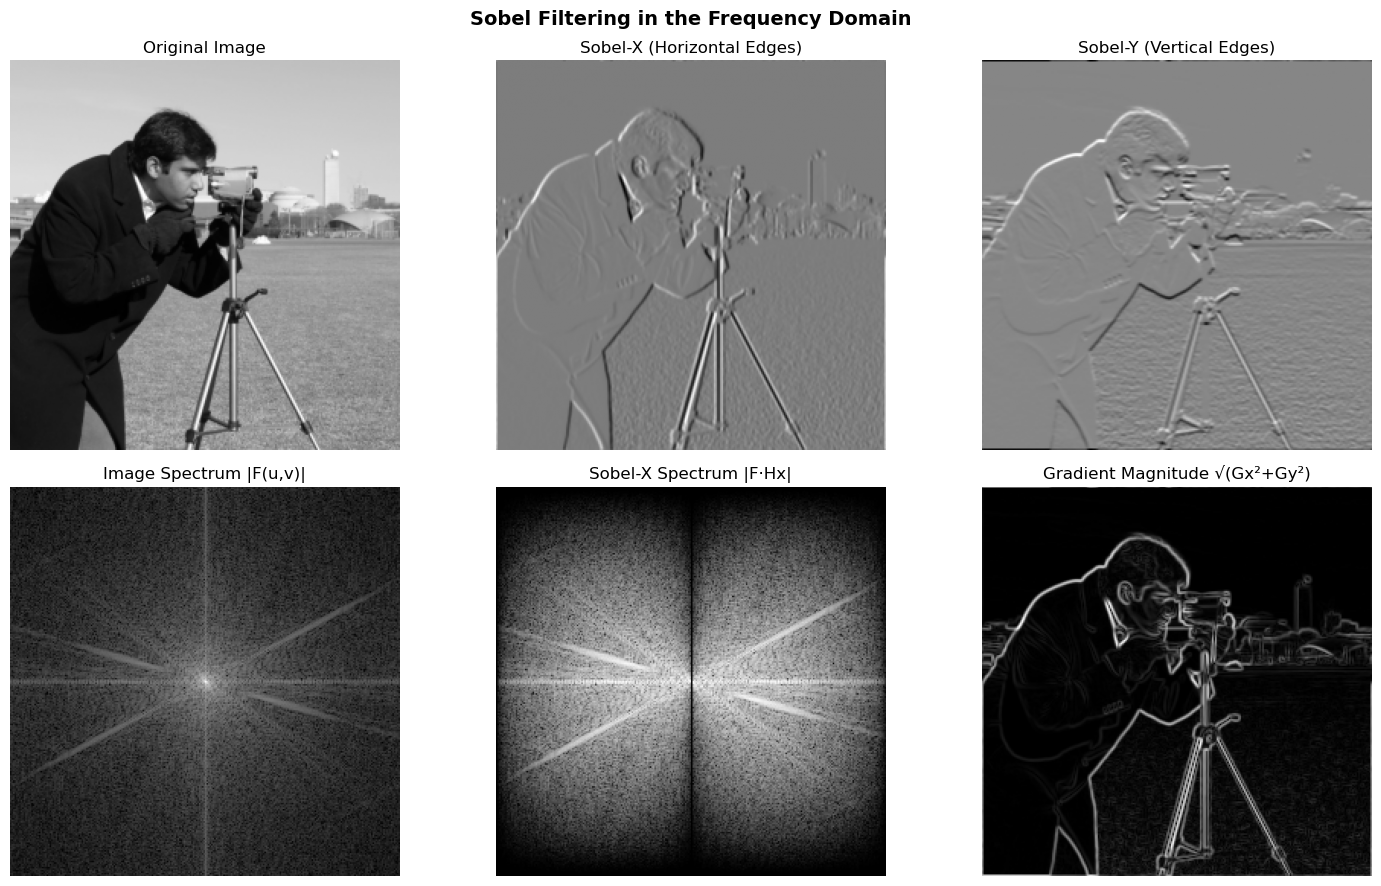

In [18]:
# Plot
def log_spectrum(F_in):
    return np.log(1 + np.abs(fftshift(F_in)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Sobel Filtering in the Frequency Domain", fontsize=14, fontweight='bold')

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel_x_img, cmap='gray')
axes[0, 1].set_title('Sobel-X (Horizontal Edges)')
axes[0, 1].axis('off')

axes[0, 2].imshow(sobel_y_img, cmap='gray')
axes[0, 2].set_title('Sobel-Y (Vertical Edges)')
axes[0, 2].axis('off')

axes[1, 0].imshow(log_spectrum(F), cmap='gray')
axes[1, 0].set_title('Image Spectrum |F(u,v)|')
axes[1, 0].axis('off')

axes[1, 1].imshow(log_spectrum(F_sobel_x), cmap='gray')
axes[1, 1].set_title('Sobel-X Spectrum |F·Hx|')
axes[1, 1].axis('off')

axes[1, 2].imshow(sobel_magnitude, cmap='gray')
axes[1, 2].set_title('Gradient Magnitude √(Gx²+Gy²)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()